<h2>Klasifikasi Tingkat Kematangan Buah Pisang</h2>
<h3>PP2: Grayscale + Deteksi Tepi Prewitt + Threshold</h3>
<h3>Ekstraksi Fitur GLCM | Klasifikasi: KNN, SVM, Random Forest</h3>


## Import Library

In [1]:
import os
import cv2 as cv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from matplotlib.colors import LinearSegmentedColormap

from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)

Code di atas digunakan untuk mengimpor berbagai library yang dibutuhkan dalam proyek **Pengolahan Citra Digital (PCD)**, yang berfokus pada preprocessing citra dan ekstraksi fitur tekstur menggunakan metode Gray Level Co-occurrence Matrix (GLCM). Library `cv2` dari OpenCV digunakan untuk membaca dan memproses citra, sementara `numpy` dan `pandas` digunakan untuk manipulasi data numerik dan struktur DataFrame. Visualisasi hasil pengolahan dilakukan menggunakan `matplotlib.pyplot` dan `seaborn`, terutama untuk menampilkan gambar, heatmap korelasi, dan confusion matrix.

Library `scikit-learn` dimanfaatkan untuk proses pembelajaran mesin, meliputi pemisahan data (`train_test_split`), serta evaluasi model dengan metrik seperti akurasi, presisi, recall, dan F1-score. Tiga algoritma klasifikasi yang digunakan adalah Random Forest, SVM, dan KNN.

In [2]:
DATASET_DIR = "./Banana Ripeness Classification Dataset"
CLASSES     = ["ripe", "rotten", "unripe"]

data      = []
labels    = []
file_name = []

for sub_folder in sorted(os.listdir(DATASET_DIR)):
    sub_folder_path = os.path.join(DATASET_DIR, sub_folder)
    if not os.path.isdir(sub_folder_path):
        continue
    sub_folder_files = os.listdir(sub_folder_path)
    count = 0
    print(sub_folder)
    for filename in tqdm(sub_folder_files):
        if count == 70:
            break
        img_path = os.path.join(sub_folder_path, filename)
        img = cv.imread(img_path)
        if img is not None:
            img = img.astype(np.uint8)
            img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
            data.append(img)
            labels.append(sub_folder)
            file_name.append(filename)
            count += 1
labels = np.array(labels)

print("\nJumlah gambar    :", len(data))
print("Jumlah label unik:", len(set(labels)))
for cls in CLASSES:
    print(f"  {cls}: {np.sum(labels == cls)} gambar")


ripe


100%|██████████| 70/70 [00:00<00:00, 509.86it/s]


rotten


100%|██████████| 70/70 [00:00<00:00, 499.76it/s]


unripe


100%|██████████| 70/70 [00:00<00:00, 554.20it/s]


Jumlah gambar    : 210
Jumlah label unik: 3
  ripe: 70 gambar
  rotten: 70 gambar
  unripe: 70 gambar


Code di atas digunakan untuk memuat dan membaca gambar dari folder `valid/` yang terdiri dari tiga subfolder kelas: **ripe**, **rotten**, dan **unripe**. Setiap gambar dibaca menggunakan `cv.imread`, kemudian dikonversi dari format BGR (default OpenCV) ke grayscale menggunakan `cv.cvtColor`. Gambar yang berhasil dimuat disimpan ke dalam list `data`, sementara nama file dan labelnya masing-masing disimpan ke `file_name` dan `labels`. Jumlah gambar dibatasi hingga **70 gambar per kelas** untuk menjaga keseimbangan data.

Output menunjukkan bahwa total **210 gambar** berhasil dimuat, dengan masing-masing kelas (ripe, rotten, dan unripe) memiliki 70 gambar dan jumlah label unik yang terdeteksi adalah 3, sesuai dengan jumlah subfolder dalam dataset.

## Data Understanding

Code di bawah digunakan untuk membuat visualisasi distribusi jumlah citra pada setiap kelas dalam dataset pisang menggunakan diagram batang (bar chart). Variabel `unique` dan `counts` diperoleh dari `np.unique(labels, return_counts=True)` yang secara otomatis menghitung jumlah kemunculan tiap label tanpa perlu menghitung manual. Diagram batang dibuat menggunakan `plt.bar()` dengan warna berbeda untuk tiap kelas (ripe, rotten, unripe) agar mudah dibedakan secara visual. Jumlah citra tiap kelas juga ditampilkan langsung di atas masing-masing batang menggunakan `plt.text()` untuk memudahkan pembacaan data. Judul, label sumbu X dan Y ditambahkan untuk memberikan konteks yang jelas pada visualisasi.

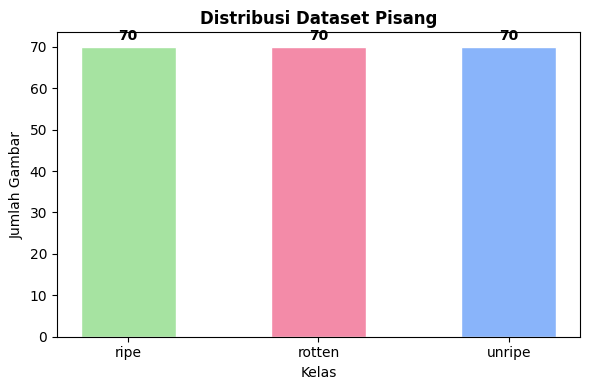

In [3]:
unique, counts = np.unique(labels, return_counts=True)
colors_bar = ["#a6e3a1", "#f38ba8", "#89b4fa"]

plt.figure(figsize=(6, 4))
bars = plt.bar(unique, counts, color=colors_bar, edgecolor="white", width=0.5)
for bar, val in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha="center", va="bottom", fontweight="bold")
plt.title("Distribusi Dataset Pisang", fontweight="bold")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")
plt.tight_layout()
plt.show()


Code di bawah digunakan untuk menampilkan 10 sampel gambar grayscale dari masing-masing kelas (ripe, rotten, dan unripe) dalam bentuk grid 3×10. Setiap baris mewakili satu kelas dengan nama kelas yang ditampilkan di sisi kiri sebagai label sumbu Y. Gambar dipilih menggunakan list comprehension yang memfilter `data` berdasarkan `labels`, kemudian divisualisasikan dalam skala abu-abu

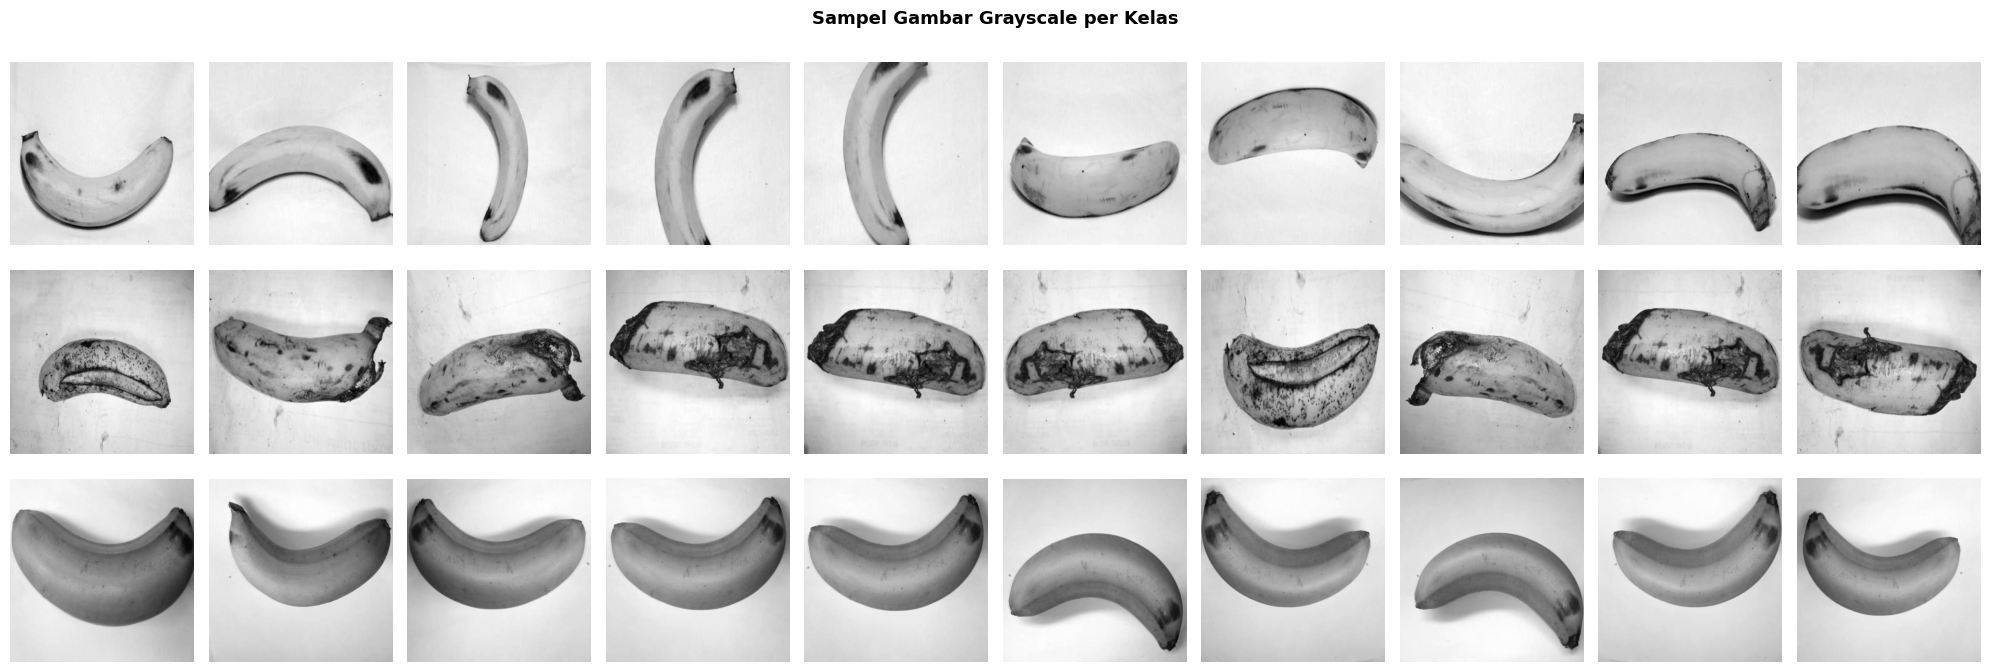

In [4]:
fig, axes = plt.subplots(3, 10, figsize=(20, 7))
fig.suptitle("Sampel Gambar Grayscale per Kelas", fontsize=13, fontweight="bold")

for row, cls in enumerate(CLASSES):
    cls_imgs = [img for img, lbl in zip(data, labels) if lbl == cls][:10]
    for col, img in enumerate(cls_imgs):
        axes[row][col].imshow(img, cmap="gray")
        axes[row][col].axis("off")
        if col == 0:
            axes[row][col].set_ylabel(cls, fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()


### Define Preprocessing Function

In [5]:
def convolution(img, kernel):
    size = len(kernel)
    pad_size = size // 2
    height, width = img.shape

    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img, dtype=np.float32)

    for i in range(height):
        for j in range(width):
            total = 0
            for r in range(size):
                for c in range(size):
                    total += int(padded[i + r, j + c]) * kernel[r][c]
            canvas[i][j] = total

    return canvas

# Kernel Prewitt
prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewittY = np.array([
    [ 1,  1,  1],
    [ 0,  0,  0],
    [-1, -1, -1]
], dtype=np.float32)

def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)
    return np.clip(canvas, 0, 255).astype(np.uint8)

def treshold(img, batas):
    baris, kolom = img.shape
    canvas = np.zeros_like(img, dtype=np.uint8)
    for i in range(baris):
        for j in range(kolom):
            if img[i, j] > batas:
                canvas[i, j] = 255
            else:
                canvas[i, j] = 0
    return canvas

def prepro2(img_gray):
    """PP2: Grayscale → Deteksi Tepi Prewitt → Threshold"""
    edges  = edge(img_gray, prewittX, prewittY)
    result = treshold(edges, 25)
    return result

Code di atas mendefinisikan seluruh fungsi preprocessing yang digunakan pada **Preprocessing 2 (PP2)**, yaitu konvolusi manual, deteksi tepi Prewitt, threshold, dan fungsi utama `prepro2()`:

1. **`convolution(img, kernel)`**  Melakukan operasi konvolusi secara manual menggunakan numpy. Citra di-padding dengan nol sebesar `pad_size = size // 2` agar ukuran output sama dengan input. Setiap piksel dihitung dengan menjumlahkan hasil perkalian elemen patch sekitarnya dengan kernel.

2. **`prewittX` dan `prewittY`** Dua kernel Prewitt 3×3 untuk mendeteksi tepi secara horizontal dan vertikal. `prewittX` mendeteksi perubahan intensitas arah horizontal (tepi vertikal), sedangkan `prewittY` mendeteksi perubahan arah vertikal (tepi horizontal).

3. **`edge(img, kernelx, kernely)`** Menghitung gradien Gx dan Gy melalui konvolusi manual, menggabungkannya dengan `|Gx| + |Gy|`, lalu menormalisasi hasil ke rentang [0, 255].

4. **`treshold(img, batas)`** Membinarisasi citra hasil deteksi tepi: piksel dengan nilai di atas `batas` diset ke 255 (putih), sisanya menjadi 0 (hitam).

5. **`prepro2(img_gray)`** Fungsi utama PP2 yang menggabungkan seluruh tahapan: deteksi tepi Prewitt lalu threshold dengan nilai 25.

### Preview Hasil Preprocessing

Code di atas menampilkan perbandingan hasil preprocessing tahap demi tahap untuk satu sampel gambar dari masing-masing kelas. Kolom pertama menampilkan citra grayscale asli, kolom kedua menunjukkan hasil deteksi tepi menggunakan operator Prewitt (tampak garis tepi objek pisang), dan kolom ketiga menampilkan hasil binerisasi menggunakan threshold. Visualisasi ini membantu memverifikasi bahwa setiap tahap preprocessing menghasilkan output yang sesuai sebelum diterapkan ke seluruh dataset.

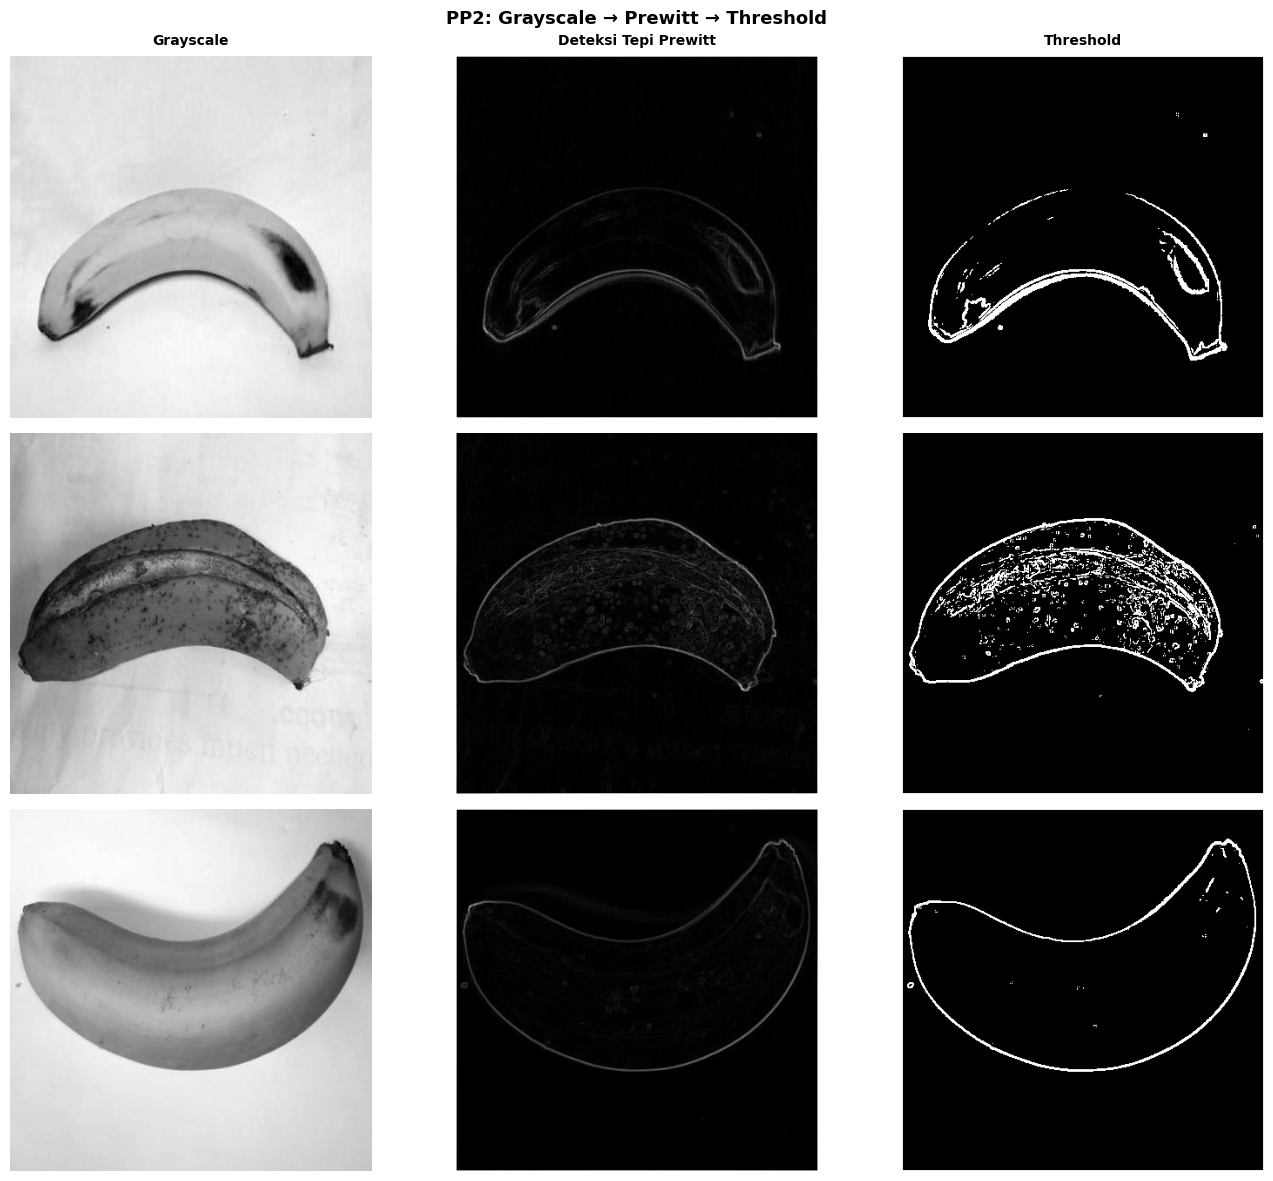

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
fig.suptitle("PP2: Grayscale → Prewitt → Threshold", fontsize=13, fontweight="bold")

col_titles = ["Grayscale", "Deteksi Tepi Prewitt", "Threshold"]
for col, title in enumerate(col_titles):
    axes[0][col].set_title(title, fontsize=10, fontweight="bold", pad=8)

sample_index = {"ripe": 10, "rotten": 15, "unripe": 4}

for row, cls in enumerate(CLASSES):
    cls_imgs = [img for img, lbl in zip(data, labels) if lbl == cls]
    sample   = cls_imgs[sample_index[cls]]
    edges    = edge(sample, prewittX, prewittY)
    binary   = treshold(edges, 25)

    axes[row][0].imshow(sample, cmap="gray")
    axes[row][0].set_ylabel(cls, fontsize=10, fontweight="bold")
    axes[row][0].axis("off")
    axes[row][1].imshow(edges, cmap="gray")
    axes[row][1].axis("off")
    axes[row][2].imshow(binary, cmap="gray")
    axes[row][2].axis("off")

plt.tight_layout()
plt.savefig("preview_pp2.png", dpi=120, bbox_inches="tight")
plt.show()


In [7]:
dataPreprocessed = []
for i in range(len(data)):
    dataPreprocessed.append(prepro2(data[i]))

print(f"Total gambar terpreprocessing: {len(dataPreprocessed)}")


Total gambar terpreprocessing: 210


Code di atas menerapkan fungsi `prepro2()` pada seluruh 210 citra dalam dataset secara berurutan menggunakan perulangan `for`. Setiap citra diproses melalui tahapan deteksi tepi Prewitt dan threshold, lalu hasilnya disimpan ke dalam list `dataPreprocessed`. Output menunjukkan bahwa seluruh **210 gambar** berhasil diproses dan siap digunakan pada tahap ekstraksi fitur GLCM.

Code di bawah menampilkan seluruh 210 citra hasil preprocessing PP2 dalam bentuk grid dengan 20 kolom. Jumlah baris dihitung secara otomatis berdasarkan total gambar dibagi jumlah kolom. Setiap citra divisualisasikan dalam skala abu-abu (`cmap="gray"`) tanpa sumbu (`axis("off")`) agar tampilan tetap bersih dan rapi. Jika jumlah subplot melebihi jumlah citra, subplot yang tidak terisi tetap disembunyikan. Visualisasi ini memungkinkan inspeksi visual menyeluruh terhadap kualitas hasil preprocessing sebelum dilanjutkan ke tahap ekstraksi fitur GLCM.

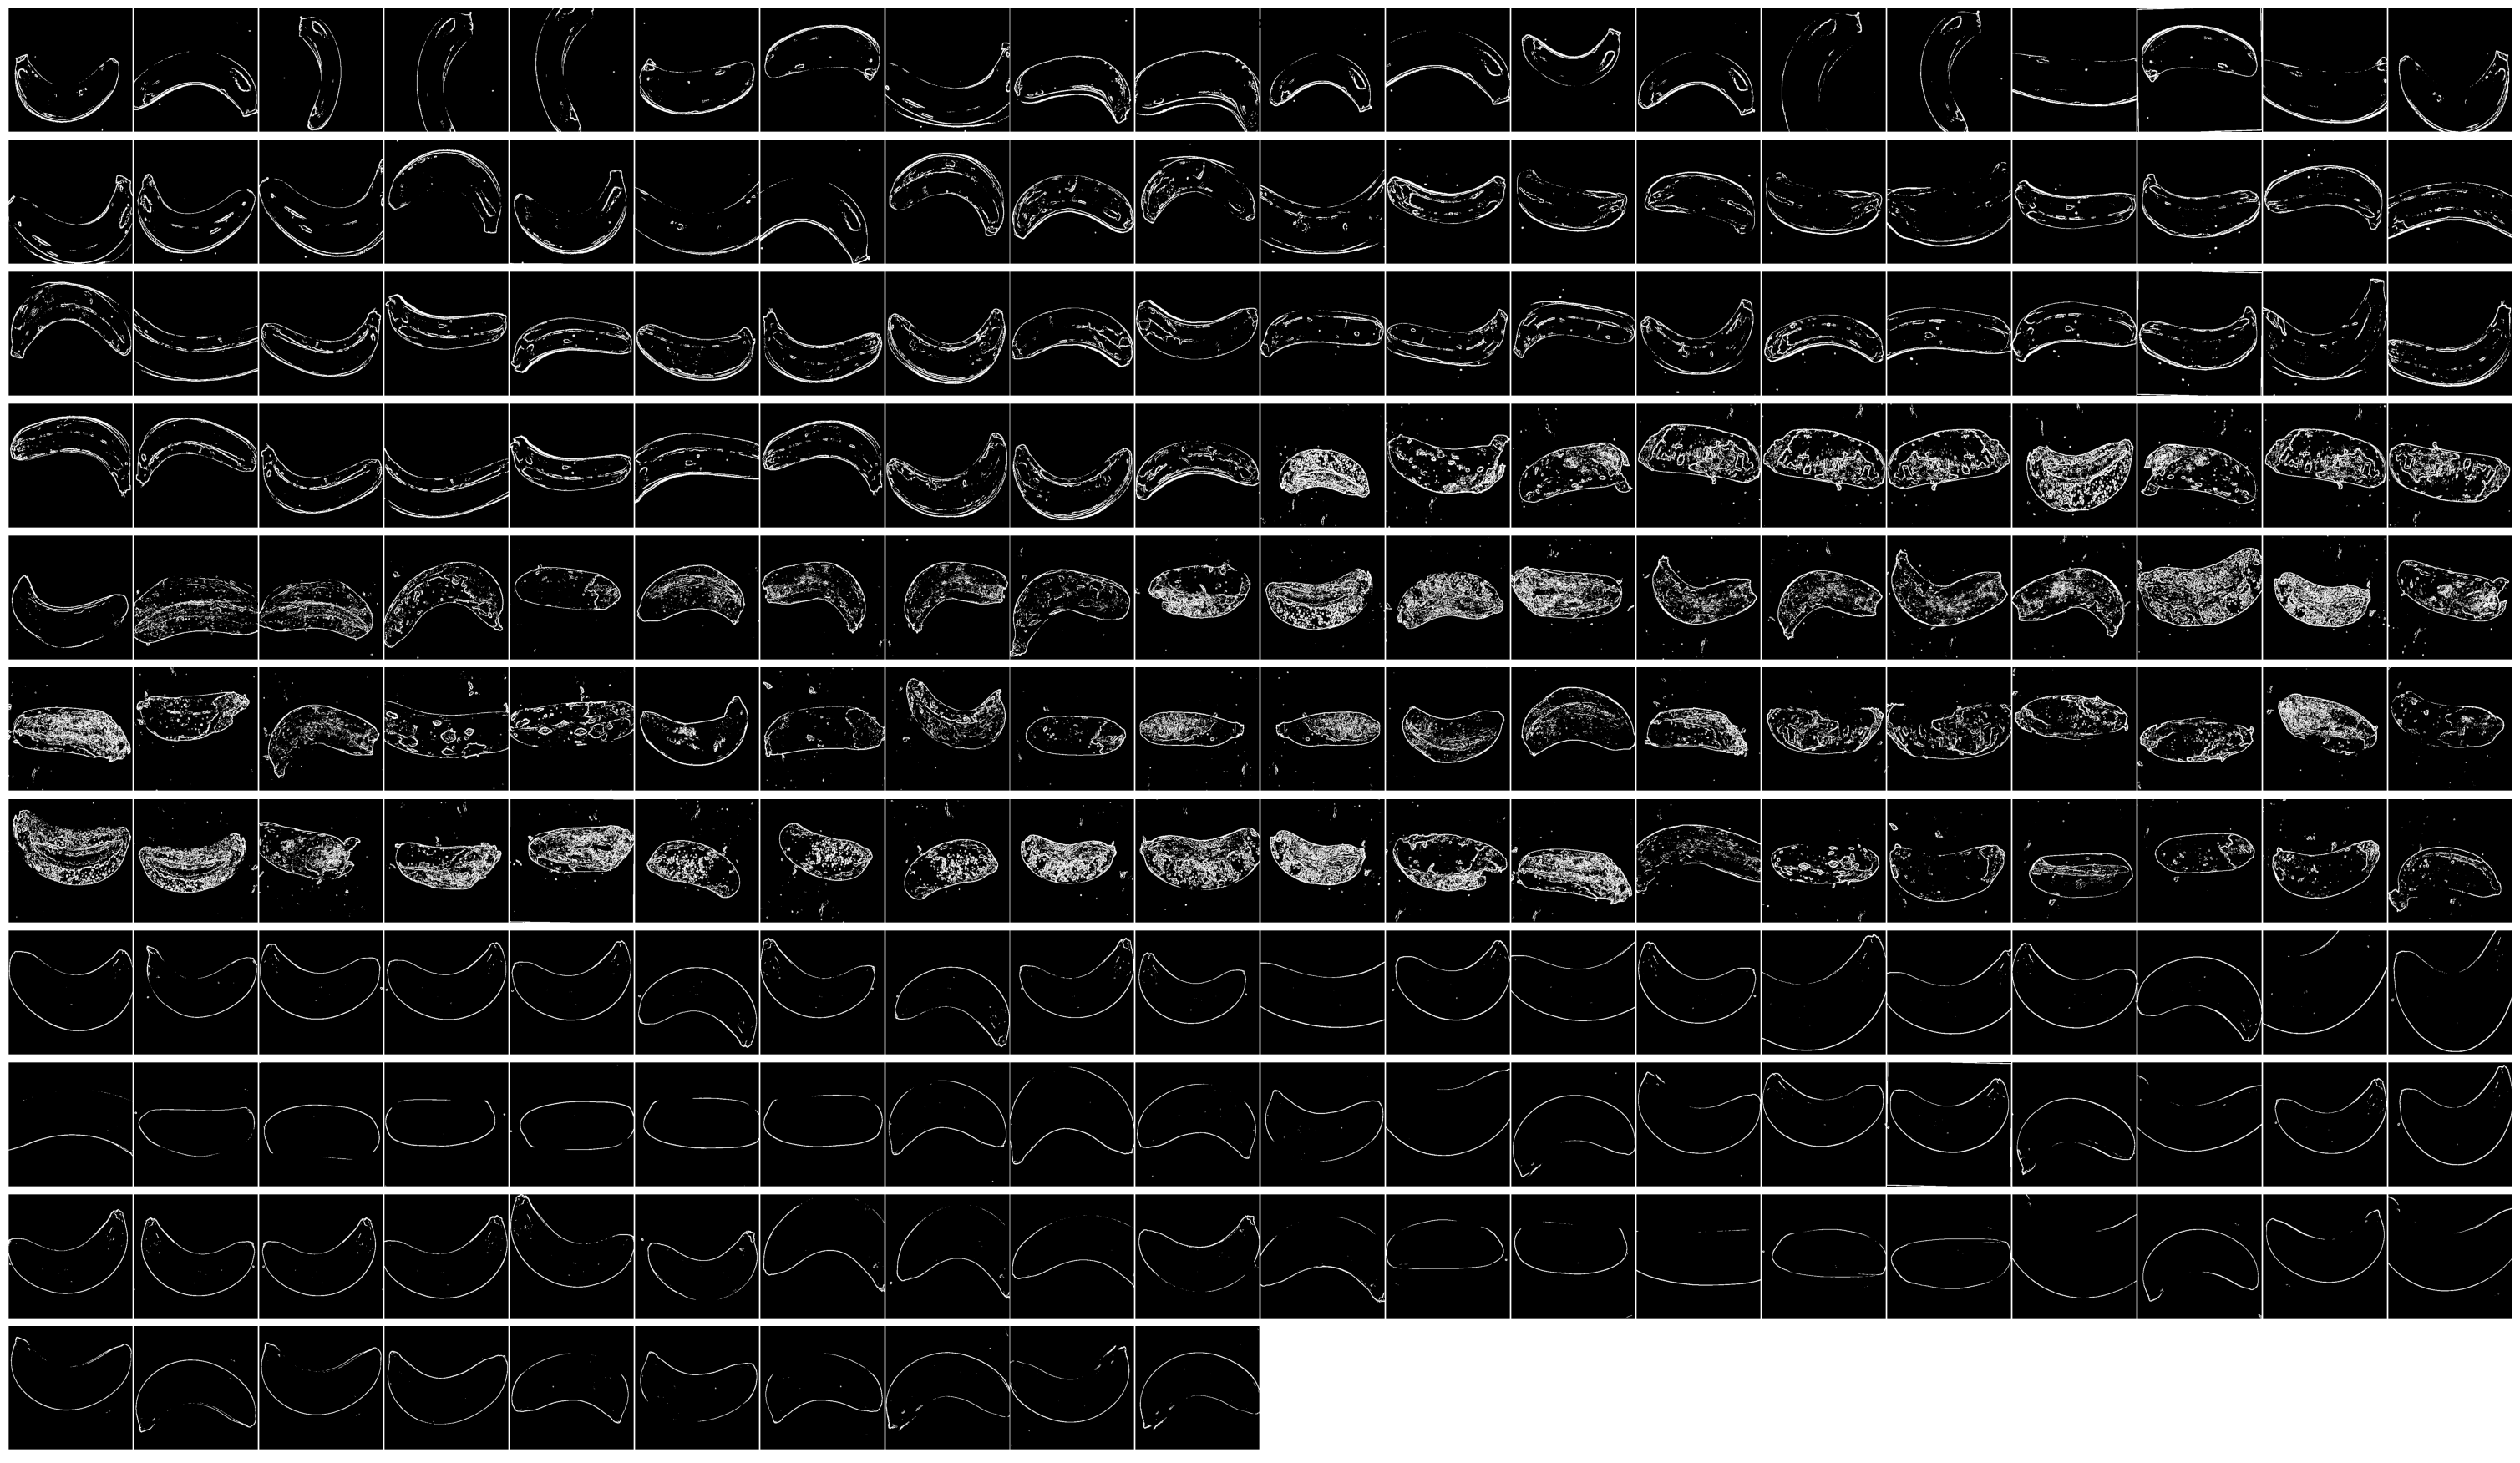

In [8]:
num_images = min(len(dataPreprocessed), 210)
cols = 20
rows = (num_images // cols) + (1 if num_images % cols else 0)

fig, axes = plt.subplots(rows, cols, figsize=(30, rows * 1.6))
fig.suptitle("Semua Gambar Hasil PP2", fontsize=12, fontweight="bold")

for i, ax in enumerate(axes.flat):
    if i < num_images:
        ax.imshow(dataPreprocessed[i], cmap="gray")
        ax.axis("off")
    else:
        ax.axis("off")

plt.tight_layout(pad=0.1)
plt.show()


In [9]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")
    glcm_matrix = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm_matrix

def correlation(matriks):   return graycoprops(matriks, 'correlation')[0, 0]
def dissimilarity(matriks): return graycoprops(matriks, 'dissimilarity')[0, 0]
def homogenity(matriks):    return graycoprops(matriks, 'homogeneity')[0, 0]
def contrast(matriks):      return graycoprops(matriks, 'contrast')[0, 0]
def ASM(matriks):           return graycoprops(matriks, 'ASM')[0, 0]
def energy(matriks):        return graycoprops(matriks, 'energy')[0, 0]
def entropyGlcm(matriks):   return entropy(matriks.ravel())

Code di atas mendefinisikan fungsi `glcm()` yang menghasilkan matriks co-occurrence tingkat keabuan (GLCM) dari sebuah citra grayscale pada sudut tertentu. Parameter `derajat` menerima nilai 0, 45, 90, atau 135, yang kemudian dikonversi ke radian untuk digunakan oleh fungsi `graycomatrix` dari `skimage.feature`. Fungsi ini menghasilkan matriks GLCM yang simetris dan ternormalisasi dengan jarak piksel 1, sehingga siap digunakan untuk ekstraksi fitur tekstur dari berbagai arah. Jika nilai sudut yang diberikan tidak valid, fungsi akan memunculkan error sebagai pengaman.

Selain itu, tujuh fungsi ekstraksi fitur juga didefinisikan:
- **`correlation`** : mengukur hubungan linear antara pasangan piksel dalam citra
- **`dissimilarity`** : mengukur tingkat ketidaksamaan antara pasangan piksel
- **`homogeneity`** : mengukur seberapa seragam tekstur dalam citra
- **`contrast`** : mengukur tingkat perbedaan intensitas antar piksel yang bersebelahan
- **`ASM`** (Angular Second Moment) : mengukur tingkat keteraturan dan keseragaman tekstur
- **`energy`** : merupakan akar dari ASM, menunjukkan konsentrasi nilai pada citra
- **`entropyGlcm`** : mengukur tingkat kompleksitas atau ketidakaturan tekstur menggunakan `scipy.stats.entropy`

In [10]:
Derajat0   = []
Derajat45  = []
Derajat90  = []
Derajat135 = []

for i in range(len(dataPreprocessed)):
    D0   = glcm(dataPreprocessed[i], 0)
    D45  = glcm(dataPreprocessed[i], 45)
    D90  = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

print(f"GLCM dihitung untuk {len(Derajat0)} gambar pada 4 sudut")

GLCM dihitung untuk 210 gambar pada 4 sudut


Code di atas menghasilkan matriks GLCM dari setiap citra hasil preprocessing pada empat sudut arah yaitu 0°, 45°, 90°, dan 135°. Pada setiap iterasi, fungsi `glcm()` dipanggil empat kali untuk tiap citra dengan sudut yang berbeda, lalu hasil matriks GLCM masing-masing disimpan ke dalam list `Derajat0`, `Derajat45`, `Derajat90`, dan `Derajat135`. Penggunaan empat sudut bertujuan untuk menangkap informasi tekstur dari berbagai arah sehingga representasi fitur menjadi lebih komprehensif dan tidak terbatas pada satu orientasi saja. Output menunjukkan bahwa GLCM berhasil dihitung untuk **210 gambar** pada keempat sudut tersebut.

In [11]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

Code di atas mendefinisikan list-list kosong untuk menyimpan nilai fitur tekstur hasil ekstraksi GLCM dari setiap citra pada masing-masing sudut 0°, 45°, 90°, dan 135°. Tujuh fitur disiapkan yaitu kontras (`Kontras`), ketidaksamaan (`dissimilarity`), homogenitas (`homogenity`), entropi (`entropy`), Angular Second Moment (`ASM`), energi (`energy`), dan korelasi (`correlation`). Dengan mendefinisikan list-list ini terlebih dahulu, proses pengumpulan nilai fitur dari setiap citra dan setiap sudut dapat dilakukan secara terstruktur dan terorganisir sebelum digunakan untuk membentuk DataFrame pada tahap selanjutnya.

In [12]:
for i in range(len(dataPreprocessed)):
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))

Code di atas mengekstraksi fitur **correlation** dari matriks GLCM pada empat sudut arah (0°, 45°, 90°, dan 135°) untuk setiap citra hasil preprocessing. Fitur korelasi mengukur hubungan linear antara pasangan piksel yang bersebelahan dalam citra — nilai korelasi yang tinggi menunjukkan adanya pola berulang yang konsisten dalam tekstur. Untuk setiap citra, fungsi `correlation()` dipanggil pada matriks GLCM dari masing-masing sudut, lalu hasilnya disimpan ke dalam list `correlation0`, `correlation45`, `correlation90`, dan `correlation135`.

In [13]:
for i in range(len(dataPreprocessed)):
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))


Code di atas mengekstraksi fitur **contrast** dari matriks GLCM pada empat sudut arah (0°, 45°, 90°, dan 135°) untuk setiap citra hasil preprocessing. Fitur kontras mengukur tingkat perbedaan intensitas antara piksel yang bersebelahan dalam citra — semakin tinggi nilai kontras, semakin besar variasi tekstur dan semakin kasar permukaan yang direpresentasikan. Untuk setiap citra, fungsi `contrast()` dipanggil pada matriks GLCM dari masing-masing sudut, lalu hasilnya disimpan ke dalam list `Kontras0`, `Kontras45`, `Kontras90`, dan `Kontras135`.

In [14]:
for i in range(len(dataPreprocessed)):
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))


Code di atas mengekstraksi fitur **dissimilarity** dari matriks GLCM pada empat sudut arah (0°, 45°, 90°, dan 135°) untuk setiap citra hasil preprocessing. Fitur dissimilarity mengukur tingkat ketidaksamaan antara pasangan piksel yang bersebelahan dalam citra — semakin besar perbedaan intensitas antar piksel, semakin tinggi nilai dissimilarity-nya. Berbeda dengan contrast yang memberikan bobot lebih besar pada perbedaan intensitas yang jauh, dissimilarity memberikan bobot yang lebih merata. Untuk setiap citra, fungsi `dissimilarity()` dipanggil pada matriks GLCM dari masing-masing sudut, lalu hasilnya disimpan ke dalam list `dissimilarity0`, `dissimilarity45`, `dissimilarity90`, dan `dissimilarity135`.

In [15]:
for i in range(len(dataPreprocessed)):
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

Code di atas mengekstraksi fitur **homogeneity** dari matriks GLCM pada empat sudut arah (0°, 45°, 90°, dan 135°) untuk setiap citra hasil preprocessing. Fitur homogenitas mengukur seberapa seragam atau konsisten distribusi nilai intensitas dalam tekstur citra — semakin tinggi nilai homogenitas, semakin halus dan seragam tekstur citra tersebut. Homogenitas bernilai tinggi ketika elemen-elemen matriks GLCM terkonsentrasi di sekitar diagonal utama. Untuk setiap citra, fungsi `homogenity()` dipanggil pada matriks GLCM dari masing-masing sudut, lalu hasilnya disimpan ke dalam list `homogenity0`, `homogenity45`, `homogenity90`, dan `homogenity135`.

In [16]:
for i in range(len(dataPreprocessed)):
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

Code di atas mengekstraksi fitur **entropy** dari matriks GLCM pada empat sudut arah (0°, 45°, 90°, dan 135°) untuk setiap citra hasil preprocessing. Fitur entropy mengukur tingkat kompleksitas atau ketidakaturan tekstur dalam citra — semakin tinggi nilai entropy, semakin acak dan tidak teratur tekstur yang terkandung dalam citra tersebut. Sebaliknya, nilai entropy yang rendah menunjukkan tekstur yang lebih seragam dan teratur. Fungsi `entropyGlcm()` menghitung entropy dengan meratakan matriks GLCM menjadi array satu dimensi menggunakan `.ravel()` sebelum dihitung menggunakan `scipy.stats.entropy`. Hasilnya disimpan ke dalam list `entropy0`, `entropy45`, `entropy90`, dan `entropy135`.

In [17]:
for i in range(len(dataPreprocessed)):
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

Code di atas mengekstraksi fitur **ASM (Angular Second Moment)** dari matriks GLCM pada empat sudut arah (0°, 45°, 90°, dan 135°) untuk setiap citra hasil preprocessing. ASM mengukur tingkat keseragaman atau keteraturan tekstur dalam citra — semakin tinggi nilai ASM, semakin seragam dan teratur teksturnya. ASM dihitung dengan menjumlahkan kuadrat dari setiap elemen matriks GLCM, sehingga nilainya akan tinggi ketika distribusi intensitas piksel sangat terkonsentrasi pada beberapa nilai tertentu. Untuk setiap citra, fungsi `ASM()` dipanggil pada matriks GLCM dari masing-masing sudut, lalu hasilnya disimpan ke dalam list `ASM0`, `ASM45`, `ASM90`, dan `ASM135`.

In [18]:
for i in range(len(dataPreprocessed)):
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

Code di atas mengekstraksi fitur **energy** dari matriks GLCM pada empat sudut arah (0°, 45°, 90°, dan 135°) untuk setiap citra hasil preprocessing. Fitur energy merupakan akar kuadrat dari ASM dan menunjukkan tingkat keseragaman atau kekompakan distribusi nilai intensitas dalam tekstur citra — semakin tinggi nilai energy, semakin homogen dan teratur tekstur citra tersebut. Energy bernilai 1 ketika citra memiliki tekstur yang benar-benar seragam dan mendekati 0 ketika teksturnya sangat acak. Untuk setiap citra, fungsi `energy()` dipanggil pada matriks GLCM dari masing-masing sudut, lalu hasilnya disimpan ke dalam list `energy0`, `energy45`, `energy90`, dan `energy135`.

Code di bawah menyusun seluruh fitur tekstur hasil ekstraksi GLCM ke dalam format tabel menggunakan `DataFrame` dari library `pandas`. Semua fitur yang telah diekstraksi — contrast, homogeneity, dissimilarity, entropy, ASM, energy, dan correlation — masing-masing dari empat sudut (0°, 45°, 90°, dan 135°), digabungkan bersama informasi `Filename` dan `Label` dalam dictionary `dataTable`, sehingga menghasilkan total **28 kolom fitur** ditambah 2 kolom metadata. DataFrame tersebut kemudian disimpan ke file `hasil_ekstraksi_2.csv` menggunakan `df.to_csv()` tanpa menyertakan index baris. File CSV ini dibaca kembali ke dalam variabel `hasilEkstrak` menggunakan `pd.read_csv()` untuk memastikan penyimpanan berhasil sekaligus mempersiapkan data untuk tahap seleksi fitur dan klasifikasi selanjutnya.

In [19]:
dataTable = {
    'Filename': file_name, 'Label': labels,
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
}

df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_2.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_2.csv')
hasilEkstrak


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,musa-acuminata-freshripe-43de8667-2653-11ec-a9...,ripe,1352.176494,1976.140804,1355.189701,2080.346930,0.979206,0.969610,0.979159,0.968007,...,0.896334,0.889990,0.946773,0.944189,0.946749,0.943393,0.750242,0.615508,0.749686,0.595233
1,musa-acuminata-freshripe-442acb3c-2653-11ec-a0...,ripe,1120.912882,1837.954420,1355.943003,1877.975613,0.982762,0.971735,0.979148,0.971120,...,0.896651,0.893243,0.948750,0.945422,0.946916,0.945115,0.792140,0.640894,0.748556,0.633074
2,musa-acuminata-freshripe-44b04409-2653-11ec-b7...,ripe,1313.758109,1684.665699,854.244092,1776.034838,0.979796,0.974092,0.986863,0.972687,...,0.927412,0.918204,0.959469,0.958924,0.963022,0.958230,0.661141,0.530896,0.779664,0.505454
3,musa-acuminata-freshripe-45145e8c-2653-11ec-8c...,ripe,1152.551552,1620.480766,691.530931,1439.252722,0.982276,0.975079,0.989365,0.977867,...,0.941378,0.934735,0.966690,0.965443,0.970246,0.966817,0.631506,0.428692,0.778903,0.492585
4,musa-acuminata-freshripe-457d3d65-2653-11ec-ab...,ripe,1186.450127,1540.438380,677.218200,1539.683263,0.981754,0.976310,0.989585,0.976322,...,0.941043,0.932707,0.966145,0.965762,0.970074,0.965768,0.624960,0.463729,0.785929,0.463992
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,musa-acuminata-freshunripe-711ace0a-1d0a-11ec-...,unripe,694.544138,1292.760052,795.486562,1228.575120,0.989319,0.980119,0.987767,0.981106,...,0.946958,0.945038,0.973897,0.971642,0.973118,0.972130,0.739214,0.454202,0.701313,0.481301
206,musa-acuminata-freshunripe-7120e889-1d0a-11ec-...,unripe,685.504518,1210.452315,787.200243,1282.188416,0.989458,0.981385,0.987894,0.980282,...,0.948093,0.945263,0.974485,0.972792,0.973701,0.972246,0.736096,0.474257,0.696946,0.443100
207,musa-acuminata-freshunripe-71d6e2c3-1d0a-11ec-...,unripe,812.059198,1417.354333,1001.137917,1462.661344,0.987512,0.978203,0.984604,0.977507,...,0.938008,0.935646,0.969955,0.967632,0.968508,0.967288,0.733467,0.485508,0.671253,0.469062
208,musa-acuminata-freshunripe-724a36b5-1d0a-11ec-...,unripe,764.601193,1352.414284,922.041242,1366.761504,0.988242,0.979202,0.985820,0.978981,...,0.941961,0.939872,0.971761,0.969579,0.970547,0.969470,0.733127,0.474139,0.678175,0.468561


Code di atas menyusun seluruh fitur tekstur hasil ekstraksi GLCM ke dalam format tabel menggunakan `DataFrame` dari `pandas`. Fitur-fitur seperti contrast, homogeneity, dissimilarity, entropy, ASM, energy, dan correlation masing-masing dari empat sudut, digabungkan bersama informasi `Filename` dan `Label` dalam dictionary `dataTable`. DataFrame tersebut kemudian disimpan ke file `hasil_ekstraksi_2.csv` dan dibaca kembali ke variabel `hasilEkstrak` untuk memastikan penyimpanan berhasil sekaligus mempersiapkan data untuk tahap seleksi fitur.

Code di bawah melakukan seleksi fitur berdasarkan korelasi antar fitur numerik dalam dataset hasil ekstraksi GLCM. Pertama, seluruh kolom fitur dihitung nilai korelasinya menggunakan `.corr()` dari `pandas`, dengan menghapus terlebih dahulu kolom non-numerik `Label` dan `Filename`. Kemudian dilakukan penyaringan terhadap fitur-fitur yang memiliki korelasi sangat tinggi satu sama lain (≥ 0.95), karena korelasi tinggi mengindikasikan redundansi informasi yang dapat menyebabkan overfitting dan meningkatkan waktu komputasi secara tidak perlu. Fitur yang terbukti redundan akan dibuang, sementara fitur yang tersisa disimpan ke dalam `x_new` dan label klasifikasi ke `y`.

Dari **28 fitur awal**, proses seleksi menghasilkan **6 fitur terpilih** yaitu `Contrast0`, `Homogeneity0`, `Correlation0`, `Correlation45`, `Correlation90`, dan `Correlation135`. Dominannya fitur korelasi pada berbagai sudut mengindikasikan bahwa hubungan linear antar piksel pada citra hasil deteksi tepi Prewitt sangat berperan dalam membedakan tingkat kematangan pisang. Untuk membantu visualisasi hubungan antar fitur terpilih, ditampilkan heatmap korelasi menggunakan `sns.heatmap()` dengan colormap Blues yang juga disimpan sebagai file `heatmap_pp2.png`.

Fitur sebelum seleksi : 28
Fitur setelah seleksi : 6
Fitur terpilih        : ['Contrast0', 'Homogeneity0', 'Correlation0', 'Correlation45', 'Correlation90', 'Correlation135']


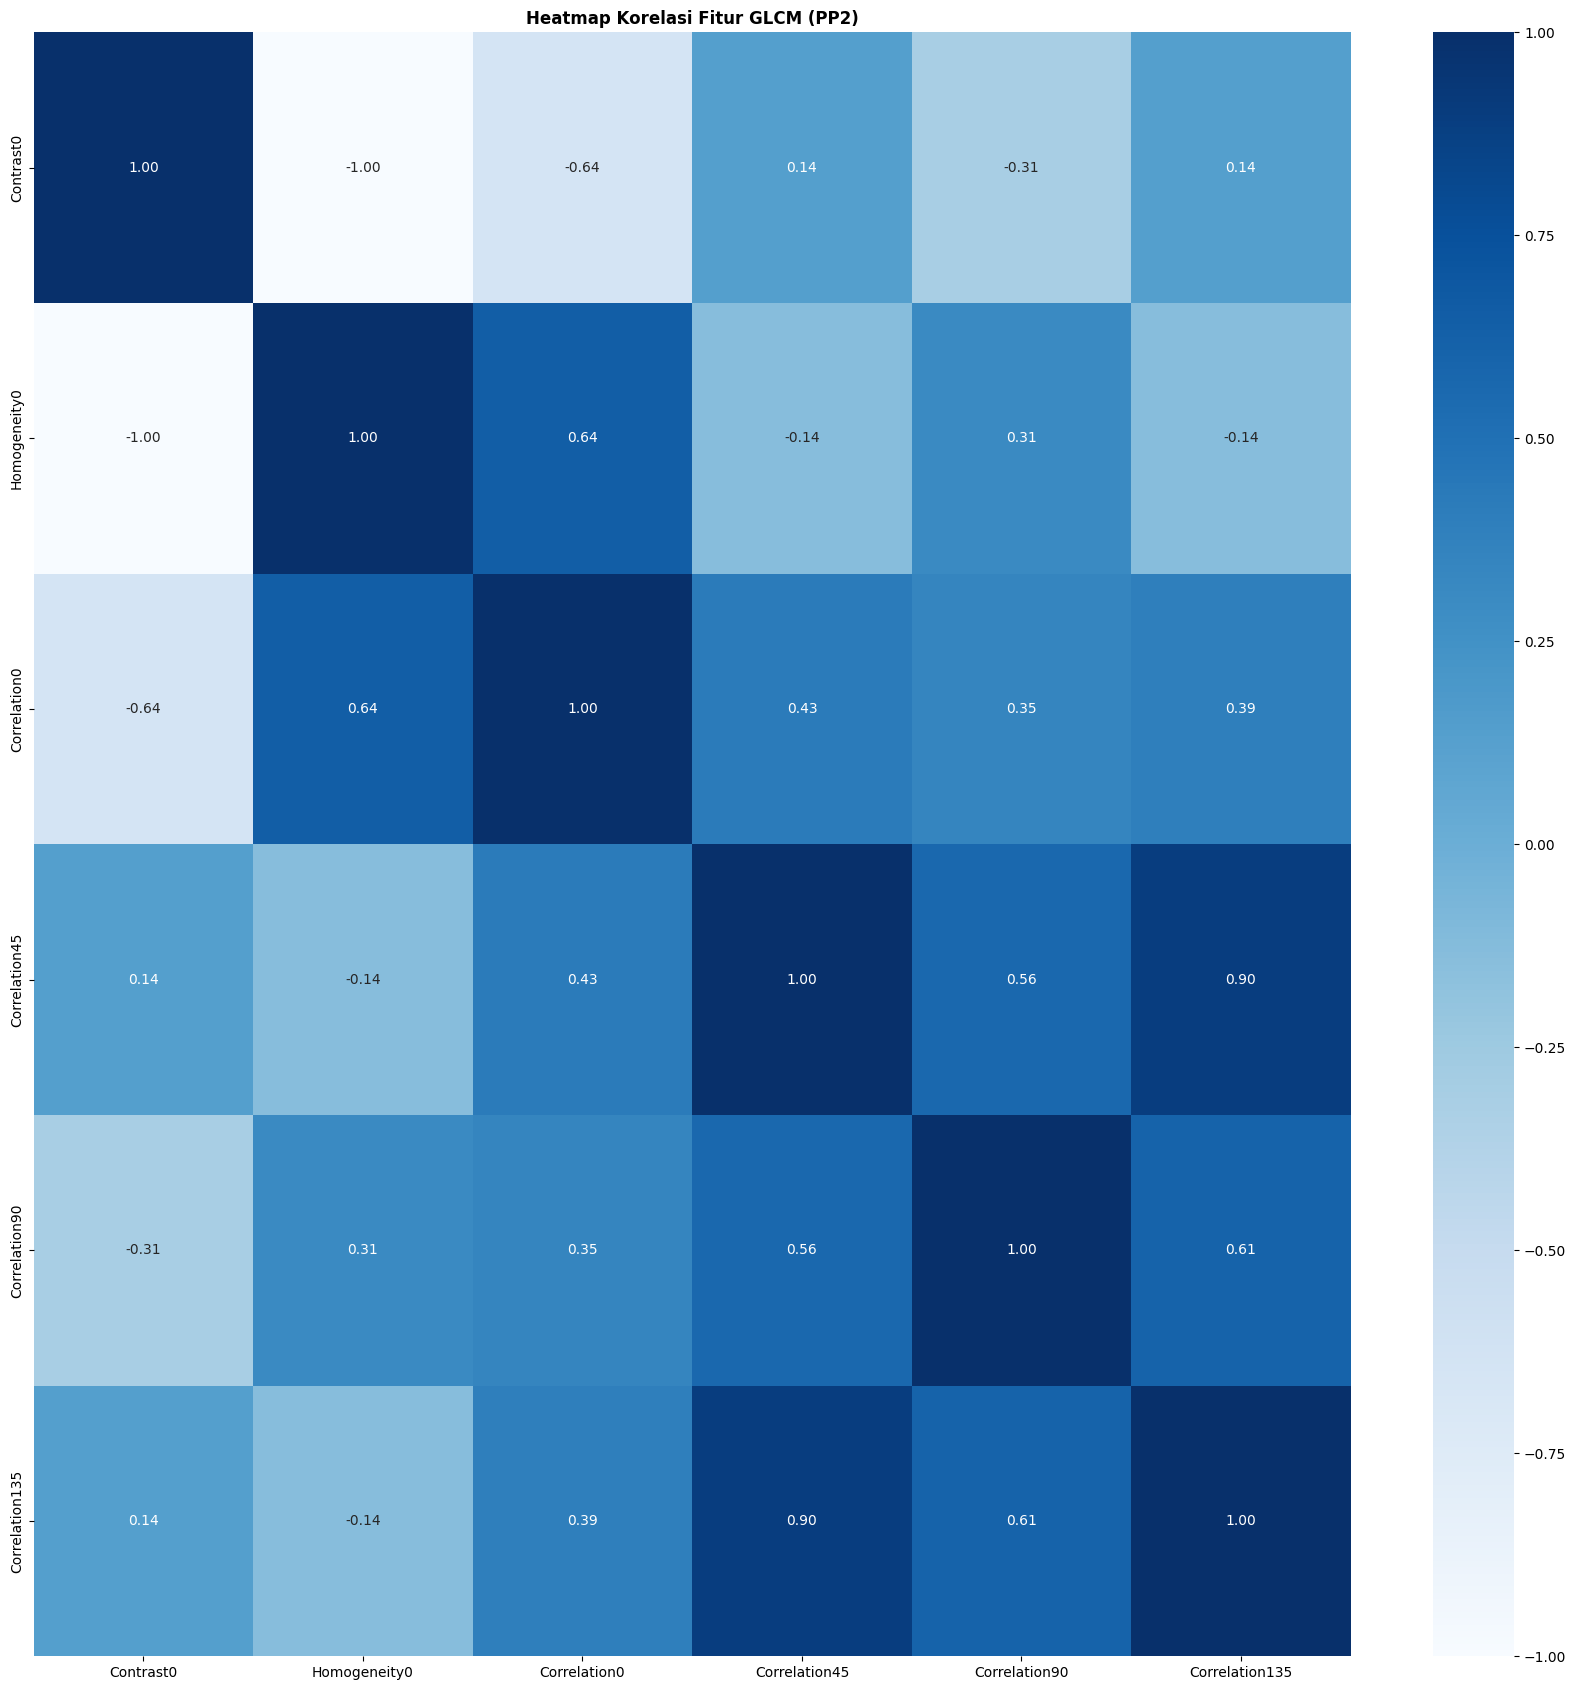

In [20]:
# Menghitung korelasi
correlation_matrix = hasilEkstrak.drop(columns=['Label', 'Filename']).corr()

# Menyaring fitur yang memiliki korelasi absolut lebih dari 0.95
threshold = 0.95
columns   = np.full((correlation_matrix.shape[0],), True, dtype=bool)
for i in range(correlation_matrix.shape[0]):
    for j in range(i+1, correlation_matrix.shape[0]):
        if correlation_matrix.iloc[i, j] >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label', 'Filename']).columns[columns]
x_new  = hasilEkstrak[select]
y      = hasilEkstrak['Label']

print(f"Fitur sebelum seleksi : 28")
print(f"Fitur setelah seleksi : {len(select)}")
print(f"Fitur terpilih        : {list(select)}")

plt.figure(figsize=(17, 17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Heatmap Korelasi Fitur GLCM (PP2)', fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_pp2.png', dpi=100, bbox_inches='tight')
plt.show()


In [21]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(168, 6)
(42, 6)


Code di atas membagi dataset fitur (`x_new`) dan label (`y`) menjadi data latih dan data uji menggunakan fungsi `train_test_split` dari `scikit-learn` dengan parameter `test_size=0.2`, yang berarti **80% data dialokasikan untuk pelatihan dan 20% untuk pengujian**. Penggunaan `random_state=42` memastikan bahwa hasil pembagian data tetap konsisten setiap kali kode dijalankan sehingga hasil eksperimen dapat direproduksi. Berdasarkan output `(168, 6)` dan `(42, 6)`, dari total 210 data terdapat **168 data latih** dan **42 data uji**, masing-masing dengan **6 fitur** yang telah dipilih dari proses seleksi fitur sebelumnya.

In [22]:
X_test  = (X_test  - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

print("Normalisasi Z-score selesai!")
print(f"X_train mean: {X_train.mean().mean():.4f}, std: {X_train.std().mean():.4f}")

Normalisasi Z-score selesai!
X_train mean: 0.0000, std: 1.0000


Code di atas melakukan normalisasi data fitur pada dataset latih (`X_train`) dan dataset uji (`X_test`) menggunakan metode **Standardization (Z-score)**. Setiap nilai fitur dikurangi rata-rata (`mean`) lalu dibagi standar deviasi (`std`) dari data latih, sehingga distribusi fitur memiliki rata-rata mendekati nol dan standar deviasi mendekati satu. Penting untuk dicatat bahwa nilai `mean` dan `std` dihitung **hanya dari data latih**, kemudian diterapkan juga ke data uji — hal ini dilakukan agar informasi statistik dari data uji tidak "bocor" ke dalam proses pelatihan sehingga evaluasi model tetap objektif. Normalisasi ini membantu meningkatkan performa dan konvergensi algoritma pembelajaran mesin, terutama untuk model seperti SVM dan KNN yang sensitif terhadap perbedaan skala antar fitur. Output menunjukkan bahwa rata-rata `X_train` mendekati **0.0000** dan standar deviasi mendekati **1.0000**, membuktikan normalisasi berhasil diterapkan dengan benar.

### Define Model

In [23]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))

rf  = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)


Code di atas mendefinisikan fungsi `generateClassificationReport()` yang digunakan untuk mencetak laporan evaluasi model secara lengkap, meliputi `classification_report` (precision, recall, F1-score per kelas), `confusion_matrix` (distribusi prediksi benar dan salah), serta nilai `accuracy_score` secara keseluruhan. Fungsi ini akan dipanggil berulang kali untuk mengevaluasi performa model pada data latih maupun data uji.

Selanjutnya, tiga model klasifikasi didefinisikan:
- **Random Forest** (`n_estimators=100`) — membangun 100 pohon keputusan secara paralel dari subset data dan fitur yang dipilih acak, lalu menggabungkan prediksi melalui voting mayoritas
- **SVM** (`kernel='rbf'`) — mencari hyperplane optimal yang memisahkan kelas dengan margin terbesar menggunakan kernel Radial Basis Function
- **KNN** (`n_neighbors=5`) — mengklasifikasikan setiap sampel berdasarkan mayoritas label dari 5 tetangga terdekat di ruang fitur

### Train Random Forest Classifier

Code di bawah melatih model **Random Forest** menggunakan data latih (`X_train`, `y_train`) melalui fungsi `rf.fit()`, kemudian mengevaluasi performanya pada dua set data secara terpisah. Pada **training set**, model mencapai akurasi sempurna **100%** yang menunjukkan model mampu mempelajari seluruh pola pada data latih dengan sangat baik. Namun pada **testing set**, akurasi turun menjadi **88.10%**, yang mengindikasikan adanya overfitting — model terlalu "menghafal" data latih sehingga kemampuan generalisasinya pada data baru menjadi lebih terbatas. Hal ini umum terjadi pada Random Forest dengan jumlah pohon yang banyak karena model cenderung sangat kompleks dan menyesuaikan diri secara berlebihan terhadap pola pada data latih.

In [24]:
rf.fit(X_train, y_train)

print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred_rf = rf.predict(X_test)
generateClassificationReport(y_test, y_pred_rf)


------Training Set------
              precision    recall  f1-score   support

        ripe       1.00      1.00      1.00        59
      rotten       1.00      1.00      1.00        56
      unripe       1.00      1.00      1.00        53

    accuracy                           1.00       168
   macro avg       1.00      1.00      1.00       168
weighted avg       1.00      1.00      1.00       168

[[59  0  0]
 [ 0 56  0]
 [ 0  0 53]]
Accuracy: 1.0

------Testing Set------
              precision    recall  f1-score   support

        ripe       1.00      0.55      0.71        11
      rotten       0.93      1.00      0.97        14
      unripe       0.81      1.00      0.89        17

    accuracy                           0.88        42
   macro avg       0.91      0.85      0.86        42
weighted avg       0.90      0.88      0.87        42

[[ 6  1  4]
 [ 0 14  0]
 [ 0  0 17]]
Accuracy: 0.8809523809523809


### Train SVM Classifier

Code di bawah melatih model **Support Vector Machine (SVM)** dengan kernel RBF menggunakan data latih melalui fungsi `svm.fit()`, kemudian mengevaluasi performanya pada training set dan testing set. Pada **training set**, SVM mencapai akurasi **98%**, sementara pada **testing set** akurasi mencapai **95.24%**. Perbedaan akurasi antara training dan testing yang sangat kecil menunjukkan bahwa SVM memiliki kemampuan generalisasi yang sangat baik dan tidak mengalami overfitting. Kernel RBF memungkinkan SVM memetakan fitur ke ruang berdimensi lebih tinggi untuk menemukan hyperplane pemisah yang optimal, sehingga efektif dalam membedakan pola tekstur antar tingkat kematangan pisang dari fitur GLCM hasil deteksi tepi Prewitt.

In [25]:
svm.fit(X_train, y_train)

print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred_svm = svm.predict(X_test)
generateClassificationReport(y_test, y_pred_svm)



------Training Set------
              precision    recall  f1-score   support

        ripe       0.95      1.00      0.98        59
      rotten       1.00      0.95      0.97        56
      unripe       0.98      0.98      0.98        53

    accuracy                           0.98       168
   macro avg       0.98      0.98      0.98       168
weighted avg       0.98      0.98      0.98       168

[[59  0  0]
 [ 2 53  1]
 [ 1  0 52]]
Accuracy: 0.9761904761904762

------Testing Set------
              precision    recall  f1-score   support

        ripe       0.91      0.91      0.91        11
      rotten       1.00      0.93      0.96        14
      unripe       0.94      1.00      0.97        17

    accuracy                           0.95        42
   macro avg       0.95      0.95      0.95        42
weighted avg       0.95      0.95      0.95        42

[[10  0  1]
 [ 1 13  0]
 [ 0  0 17]]
Accuracy: 0.9523809523809523


### Train KNN Classifier

Code di bawah melatih model **K-Nearest Neighbors (KNN)** dengan k=5 menggunakan data latih melalui fungsi `knn.fit()`, kemudian mengevaluasi performanya pada training set dan testing set. Pada **training set**, KNN mencapai akurasi **97%**, sementara pada **testing set** akurasi mencapai **95.24%**. Perbedaan akurasi yang kecil antara training dan testing menunjukkan bahwa KNN mampu menggeneralisasi dengan baik pada data baru. KNN mengklasifikasikan setiap sampel berdasarkan mayoritas label dari 5 tetangga terdekat di ruang fitur GLCM, hasil yang setara dengan SVM pada data uji mengindikasikan bahwa fitur GLCM hasil PP2 memiliki distribusi yang cukup konsisten antara data latih dan data uji, sehingga pendekatan berbasis kedekatan jarak yang digunakan KNN dapat bekerja secara efektif.

In [26]:
knn.fit(X_train, y_train)

print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred_knn = knn.predict(X_test)
generateClassificationReport(y_test, y_pred_knn)



------Training Set------
              precision    recall  f1-score   support

        ripe       0.92      1.00      0.96        59
      rotten       1.00      0.93      0.96        56
      unripe       1.00      0.98      0.99        53

    accuracy                           0.97       168
   macro avg       0.97      0.97      0.97       168
weighted avg       0.97      0.97      0.97       168

[[59  0  0]
 [ 4 52  0]
 [ 1  0 52]]
Accuracy: 0.9702380952380952

------Testing Set------
              precision    recall  f1-score   support

        ripe       0.91      0.91      0.91        11
      rotten       1.00      1.00      1.00        14
      unripe       0.94      0.94      0.94        17

    accuracy                           0.95        42
   macro avg       0.95      0.95      0.95        42
weighted avg       0.95      0.95      0.95        42

[[10  0  1]
 [ 0 14  0]
 [ 1  0 16]]
Accuracy: 0.9523809523809523


## Evaluation With Confusion Matrix

Code di bawah mendefinisikan fungsi `plot_confusion_matrix()` untuk menampilkan confusion matrix dari hasil prediksi model secara visual. Fungsi ini menerima label asli (`y_true`), prediksi model (`y_pred`), dan judul plot (`title`). Confusion matrix dihitung menggunakan `confusion_matrix()` dari `sklearn`, lalu divisualisasikan menggunakan `ConfusionMatrixDisplay` dengan colormap Blues. Label kelas yang ditampilkan pada sumbu confusion matrix sesuai dengan `CLASSES` yaitu ripe, rotten, dan unripe.

Fungsi ini kemudian dipanggil untuk ketiga model yang telah dilatih — Random Forest, SVM, dan KNN — pada data uji. Confusion matrix memudahkan identifikasi distribusi prediksi benar dan salah untuk setiap kelas, sehingga dapat diketahui kelas mana yang paling sering salah diklasifikasikan oleh masing-masing model.

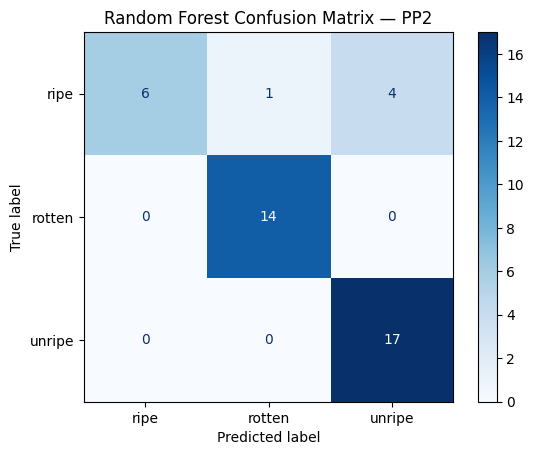

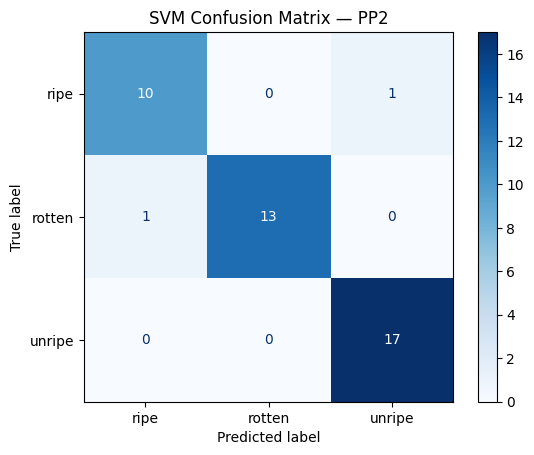

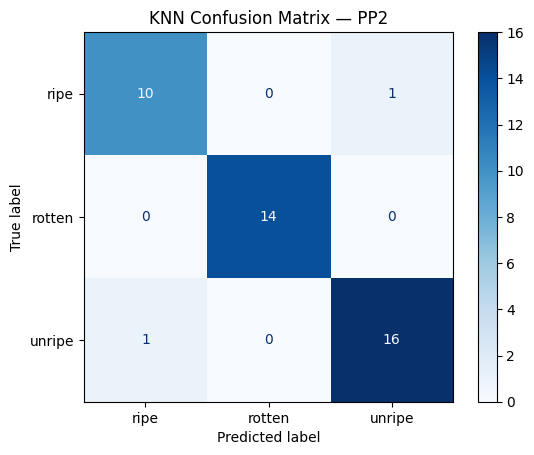

In [27]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

plot_confusion_matrix(y_test, y_pred_rf,  "Random Forest Confusion Matrix — PP2")
plot_confusion_matrix(y_test, y_pred_svm, "SVM Confusion Matrix — PP2")
plot_confusion_matrix(y_test, y_pred_knn, "KNN Confusion Matrix — PP2")


Code di atas mendefinisikan fungsi `plot_confusion_matrix()` untuk menampilkan confusion matrix dari hasil prediksi model menggunakan colormap Blues. Fungsi ini dipanggil untuk ketiga model (Random Forest, SVM, dan KNN) pada data uji, sehingga dapat dilihat distribusi prediksi benar dan salah untuk setiap kelas (ripe, rotten, unripe). Confusion matrix membantu mengidentifikasi kelas mana yang paling sering salah diklasifikasikan oleh masing-masing model.

Code di bawah menghitung empat metrik evaluasi, **accuracy**, **precision**, **recall**, dan **F1-score** untuk ketiga model (KNN, SVM, dan Random Forest) pada data uji. Metrik precision, recall, dan F1-score dihitung dengan `average="weighted"` agar perbedaan jumlah sampel antar kelas diperhitungkan secara proporsional. Seluruh hasil kemudian dirangkum dalam sebuah `DataFrame` perbandingan yang dibulatkan hingga 4 desimal dan disimpan ke file `hasil_pp2.csv` untuk referensi lebih lanjut.

Berdasarkan hasil evaluasi, **KNN dan SVM** sama-sama menghasilkan akurasi tertinggi sebesar **0.9524 (95.24%)** pada data uji, sementara **Random Forest** menghasilkan akurasi lebih rendah yaitu **0.8810 (88.10%)**. Tabel perbandingan ini akan digunakan sebagai acuan dalam analisis perbandingan antar preprocessing pada tahap akhir.

In [28]:
acc_knn  = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn, average="weighted", zero_division=0)
rec_knn  = recall_score(y_test, y_pred_knn, average="weighted", zero_division=0)
f1_knn   = f1_score(y_test, y_pred_knn, average="weighted", zero_division=0)

acc_svm  = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm, average="weighted", zero_division=0)
rec_svm  = recall_score(y_test, y_pred_svm, average="weighted", zero_division=0)
f1_svm   = f1_score(y_test, y_pred_svm, average="weighted", zero_division=0)

acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, average="weighted", zero_division=0)
rec_rf  = recall_score(y_test, y_pred_rf, average="weighted", zero_division=0)
f1_rf   = f1_score(y_test, y_pred_rf, average="weighted", zero_division=0)

df_hasil = pd.DataFrame({
    "Classifier": ["KNN", "SVM", "Random Forest"],
    "Accuracy"  : [acc_knn,  acc_svm,  acc_rf],
    "Precision" : [prec_knn, prec_svm, prec_rf],
    "Recall"    : [rec_knn,  rec_svm,  rec_rf],
    "F1-Score"  : [f1_knn,   f1_svm,   f1_rf],
})
df_hasil = df_hasil.round(4)
df_hasil.to_csv("hasil_pp2.csv", index=False)
print("Tabel Perbandingan PP2:")
df_hasil

Tabel Perbandingan PP2:


,Classifier,Accuracy,Precision,Recall,F1-Score
0,KNN,0.9524,0.9524,0.9524,0.9524
1,SVM,0.9524,0.9537,0.9524,0.9523
2,Random Forest,0.8810,0.9007,0.8810,0.8689


Code di bawah membuat visualisasi perbandingan performa ketiga model klasifikasi (KNN, SVM, dan Random Forest) dalam bentuk diagram batang berkelompok. Keempat metrik evaluasi accuracy, precision, recall, dan F1-score ditampilkan secara berdampingan untuk masing-masing model dengan warna berbeda agar mudah dibedakan. Nilai tiap batang juga ditampilkan langsung di atasnya menggunakan `ax.text()` untuk memudahkan pembacaan. Grafik disimpan sebagai file `grafik_pp2.png` dan ditampilkan menggunakan `plt.show()`.

Dari visualisasi ini terlihat bahwa **KNN dan SVM** secara konsisten unggul di seluruh metrik dengan nilai sekitar **0.95**, sementara **Random Forest** menunjukkan nilai yang lebih rendah di semua metrik sekitar **0.88-0.90**. Pola ini mengkonfirmasi bahwa untuk PP2 dengan deteksi tepi Prewitt, KNN dan SVM lebih mampu memanfaatkan informasi fitur GLCM yang dihasilkan dibandingkan Random Forest.

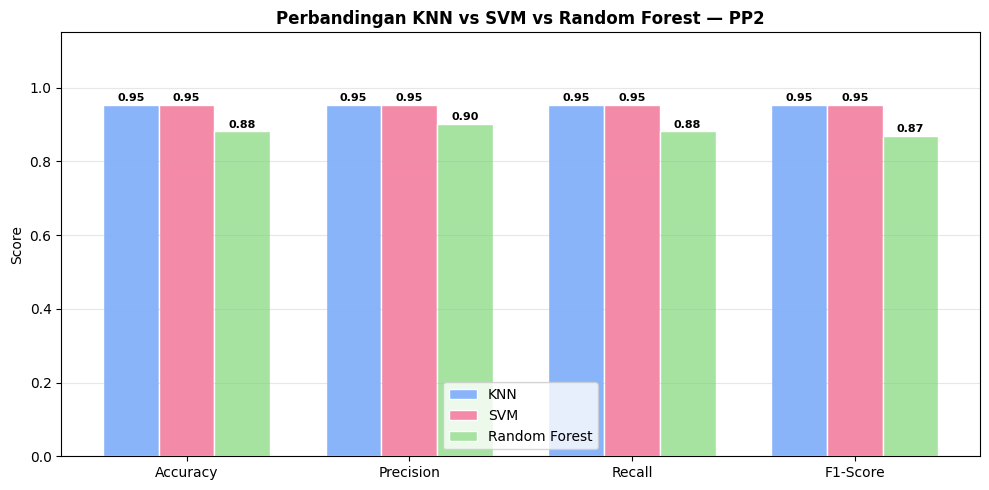

In [29]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
x       = np.arange(len(metrics))
width   = 0.25
clr     = ["#89b4fa", "#f38ba8", "#a6e3a1"]

fig, ax = plt.subplots(figsize=(10, 5))
for i, (clf, color) in enumerate(zip(["KNN", "SVM", "Random Forest"], clr)):
    vals = df_hasil[df_hasil["Classifier"] == clf][metrics].values.flatten()
    bars = ax.bar(x + i * width, vals, width, label=clf, color=color, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{v:.2f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_title("Perbandingan KNN vs SVM vs Random Forest — PP2", fontweight="bold")
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("grafik_pp2.png", dpi=120, bbox_inches="tight")
plt.show()


Code di bawah mengidentifikasi model dengan performa terbaik berdasarkan nilai akurasi tertinggi menggunakan `df_hasil["Accuracy"].idxmax()` untuk menemukan indeks baris dengan akurasi maksimum, lalu menampilkan seluruh metrik evaluasinya secara terformat. Berdasarkan hasil yang diperoleh, **KNN** menjadi model terbaik pada PP2 dengan akurasi **0.9524 (95.24%)**, precision **0.9524**, recall **0.9524**, dan F1-score **0.9524**. Nilai yang seragam di semua metrik menunjukkan bahwa KNN tidak hanya akurat secara keseluruhan, tetapi juga konsisten dalam mengenali setiap kelas kematangan pisang (ripe, rotten, dan unripe) secara seimbang.

In [30]:
best = df_hasil.loc[df_hasil["Accuracy"].idxmax()]
print("=" * 40)
print("  HASIL TERBAIK PP2")
print("=" * 40)
print(f"  Classifier : {best['Classifier']}")
print(f"  Accuracy   : {best['Accuracy']:.4f}")
print(f"  Precision  : {best['Precision']:.4f}")
print(f"  Recall     : {best['Recall']:.4f}")
print(f"  F1-Score   : {best['F1-Score']:.4f}")
print("=" * 40)


  HASIL TERBAIK PP2
  Classifier : KNN
  Accuracy   : 0.9524
  Precision  : 0.9524
  Recall     : 0.9524
  F1-Score   : 0.9524


Berdasarkan hasil perbandingan ketiga model pada PP2 (Grayscale + Deteksi Tepi Prewitt + Threshold), **KNN** dan **SVM** menunjukkan performa terbaik dengan akurasi **0.9524** pada data uji. Random Forest memiliki akurasi lebih rendah (0.8810) akibat overfitting yang terindikasi dari perbedaan besar antara akurasi training (100%) dan testing (88.10%).

Pada **Preprocessing 2 (PP2)**, citra pisang diproses melalui tiga tahap: konversi ke grayscale, deteksi tepi menggunakan operator Prewitt (konvolusi manual), dan binarisasi menggunakan threshold. Tujuan preprocessing ini adalah menonjolkan struktur tepi dan batas objek pisang yang dapat membantu membedakan tingkat kematangan berdasarkan pola tekstur permukaannya.

Dari 28 fitur GLCM yang diekstraksi pada empat sudut (0°, 45°, 90°, 135°), proses seleksi fitur berbasis korelasi menyaring hingga tersisa **6 fitur representatif** yaitu Contrast0, Homogeneity0, Correlation0, Correlation45, Correlation90, dan Correlation135. Fitur dominan yang terpilih adalah **correlation pada berbagai sudut**, yang mengindikasikan bahwa hubungan linear antar piksel pada citra tepi pisang sangat berperan dalam membedakan tingkat kematangan.

Hasil klasifikasi menunjukkan bahwa **KNN dan SVM** masing-masing menghasilkan akurasi tertinggi sebesar **95.24%** pada data uji. KNN memanfaatkan kedekatan jarak fitur GLCM antar gambar, sementara SVM membangun hyperplane pemisah optimal yang mampu menggeneralisasi dengan baik. **Random Forest** menghasilkan akurasi lebih rendah (88.10%) akibat overfitting yang terlihat dari perbedaan signifikan antara akurasi training (100%) dan testing (88.10%).

Secara keseluruhan, PP2 dengan deteksi tepi Prewitt memberikan hasil yang baik terutama untuk KNN dan SVM, mengindikasikan bahwa informasi tepi citra pisang cukup representatif sebagai fitur untuk klasifikasi kematangan.